# **Metode Finite Element (FEM)**

Metode finite element (FEM) adalah sebuah cara untuk mengubah persamaan diferensial parsial (PDE) yang sifatnya kontinu menjadi persamaan sistem linier atau diskrit non-linier. Metode ini sangat populer di bidang Teknik dan Mekanika Solid, meskipun sebenarnya bisa digunakan untuk bidang apa saja.      
Metode seperti membagi suatu objek atau daerah menjadi banyak elemen kecil yang jumlahnya terbatas, lalu dihitung satu per satu untuk mendapatkan solusi.

Ide utama dalam FEM adalah kita memikirkan fungsi kontinu $f(x)$ sebagai kombinasi linier dari sejumlah fungsi dasar yang terbatas:
$$
    f_h(x) = \sum_{i=0}^N w_i \phi_i(x) \tag{1}
$$


Di mana $\phi_i(x)$ adalah fungsi dasar dan $w_i$ adalah sekumpulan bobot. Kita telah melihat dekomposisi yang serupa pada Spectral Methods. Namun, alih-alih menggunakan fungsi basis global seperti $\sin(kx)$ atau polinomial Chebyshev, pada metode ini kita (sebagian besar) akan menggunakan polinomial berbentuk potongan (piecewise polynomials).

### **Fungsi Linear Sepenggal pada Satu Dimensi (P1)**

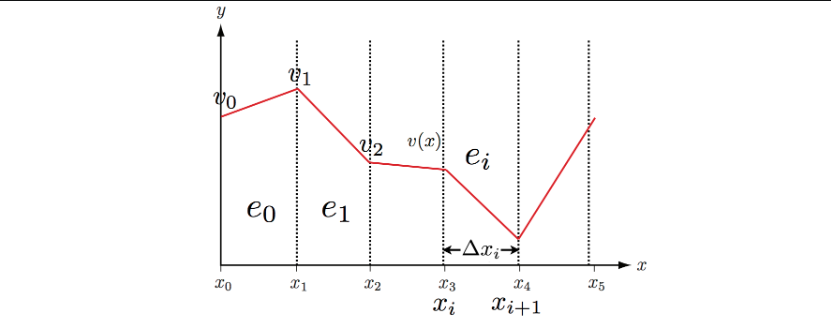

Sebagai contoh, perhatikan fungsi linear sepenggal (piecewise linear)
"connect the dots" yang ditunjukkan pada gambar di atas, di mana kita telah
menguraikan suatu interval $I=[x_0,x_5]$ menjadi 5 sub-interval atau
"elemen" $e_i=[x_i,x_{i+1}]$ dengan $i=1\ldots4$. Pada setiap interval
tersebut, fungsi $v_h$ merupakan fungsi linear terhadap $x$, dan setiap
segmen bersifat kontinu pada batas elemen. Gambar ini dimodifikasi dari
Gambar 1.1 oleh Claes Johnson Larson dan Fredrik Bengzon.

Walaupun $v_h(x)$ merupakan fungsi kontinu yang dapat dievaluasi untuk
setiap nilai $x$, perlu dipahami bahwa sebenarnya hanya terdapat 6
derajat kebebasan (degrees of freedom) yang bersesuaian dengan
nilai pada titik simpul (node), yaitu
$$
\vec{v}=[v_0,v_1,v_2,v_3,\ldots,v_5].\tag{2}
$$

Dengan hanya mengubah keenam nilai ini, kita dapat menghasilkan jumlah
tak hingga fungsi linear sepenggal pada triangulasi ini. Ruang fungsi
berdimensi hingga ini disebut $\mathcal{V}_h$, yang sepenuhnya
dideskripsikan oleh sebuah mesh elemen dan sebuah interpolan pada
setiap elemen.

### **Fungsi Basis Global**
Diberikan suatu ruang fungsi diskrit $\mathcal{V}_h$, kita seharusnya
dapat mendeskripsikan setiap fungsi $v_h \in \mathcal{V}_h$ dalam
bentuk sekumpulan fungsi basis yang merentang ruang tersebut.
Dalam kasus ruang fungsi linear sepenggal satu dimensi (1-D),
fungsi basis global diberikan oleh ``Hat Functions'' sebagai berikut
$$
\phi_i(x) = \left\{
\begin{array}{ll}
(x - x_{i-1})/\Delta x_{i-1}, & x\in e_{i-1} \\
(x_i - x)/\Delta x_{i}, & x\in e_{i} \\
0, & \text{lainnya} \\
\end{array}
\right. \tag{3}
$$

Fungsi ini memiliki sifat penting yaitu $\phi_i(x_j) = \delta_{ij}$.
Sebuah contoh fungsi hat ditunjukkan pada Gambar dari Larson dan Bengzon.
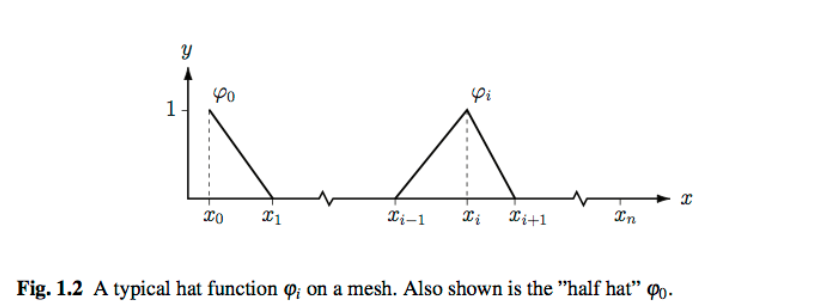
Meskipun hal ini tidak sepenuhnya jelas, kita dapat membangun semua
fungsi linear sepenggal dalam $\mathcal{V}_h$ sebagai kombinasi linear
dari fungsi-fungsi hat tersebut, yaitu
$$
f_h(x) = \sum_{i=0}^5 w_i\phi_i(x) \tag{4}
$$

### **Fungsi Basis Lokal**

Untuk memperjelas hal ini, perlu dilihat bagaimana fungsi-fungsi
basis tersebut melakukan interpolasi terhadap $v$ pada satu elemen.

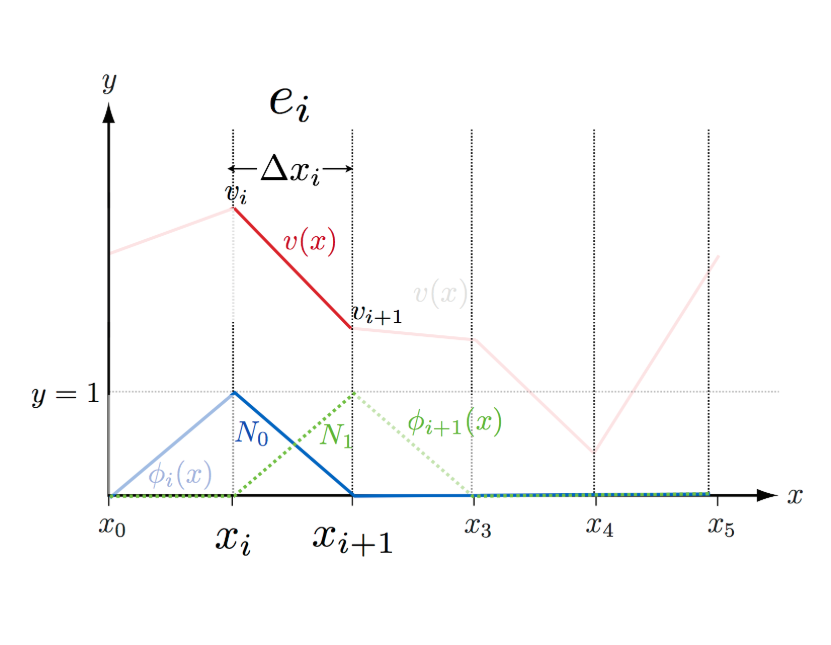

**Gambar: Definisi Fungsi Basis Global dan Lokal**


Perhatikan hanya bagian dari $v(x)$ yang berada pada elemen $e_i$.
Jelas bahwa satu-satunya fungsi basis global yang memiliki
dukungan (support) pada elemen $e_i$ adalah $\phi_i(x)$ dan
$\phi_{i+1}(x)$. Kita menyatakan bahwa pada elemen ini berlaku

$$
v(x) = v_i\phi_i(x) + v_{i+1}\phi_{i+1}(x)
\quad \text{untuk} \quad
x \in [x_i,x_{i+1}]\tag{5}

$$
Hal ini jelas benar pada titik-titik simpul (node) karena
sifat bahwa $\phi_i(x_j)=\delta_{ij}$.

Di antara titik-titik simpul, kita mengharapkan bahwa $\phi_i$ dan
$\phi_{i+1}$ memberikan interpolasi linear. Jika kita hanya
mempertimbangkan \textit{fungsi basis lokal} yang merupakan bagian dari
$\phi_i$ dan $\phi_{i+1}$ pada elemen $e_i$

\begin{align}
N_0(x) &= (x_{i+1} - x)/(x_{i+1} - x_i)\tag{6.1}\\
N_1(x) &= (x - x_i)/(x_{i+1} - x_i)\tag{6.2}
\end{align}

maka menjadi jelas bahwa fungsi-fungsi ini hanyalah polinomial
Lagrange orde 1 yang menginterpolasi setiap fungsi linear pada interval
$[x_i,x_{i+1}]$. Sebagai pengecekan, misalkan $x^* = x_i + s \Delta x_i$
di mana $s$ adalah jarak fraksional pada elemen dengan panjang
$\Delta x_i = x_{i+1} - x_i$, maka

\begin{align}
N_0(x^*) &= (x_{i+1} - x_i - s\Delta x_i)/\Delta x_i = (1 - s)\tag{7.1}\\
N_1(x^*) &= (x_i + s\Delta x_i - x_i)/\Delta x_i = s \tag{7.2}
\end{align}

sehingga di dalam $e_i$

$$
v(x) = v_i N_0(x) + v_{i+1} N_1(x) = v_i(1 - s) + v_{i+1}s \tag{8}
$$

dengan $s \in [0,1]$.

Dengan demikian, fungsi penuh $v(x)$ pada seluruh domain
$\Omega = [x_0,x_5]$ hanyalah gabungan dari bagian-bagian linear lokal
ini. Sepanjang pengantar ini, kita sering berpindah antara
pandangan global dan pandangan elemen, tergantung pada kerangka
acuan mana yang lebih mudah digunakan.

### **Ruang Fungsi Polinomial Orde Lebih Tinggi**

Ruang fungsi linear sepenggal sering disebut sebagai $P_1$,
namun terdapat pilihan lain. Sebagai contoh, ruang fungsi
kuadratik sepenggal ($P_2$) memiliki sekumpulan fungsi basis
lokal yang merupakan polinomial Lagrange orde 2 dan
memerlukan tiga derajat kebebasan pada setiap node.
Fungsi basis global kemudian dibangun dari fungsi basis
lokal tersebut.

Gambar berikut menunjukkan sebagian fungsi basis untuk
$P_2$, yang berbeda untuk derajat kebebasan pada pusat
dan pada tepi elemen (gambar asli dari [Introduction to Finite Element Methods](http://hplgit.github.io/INF5620/doc/pub/sphinx-fem)
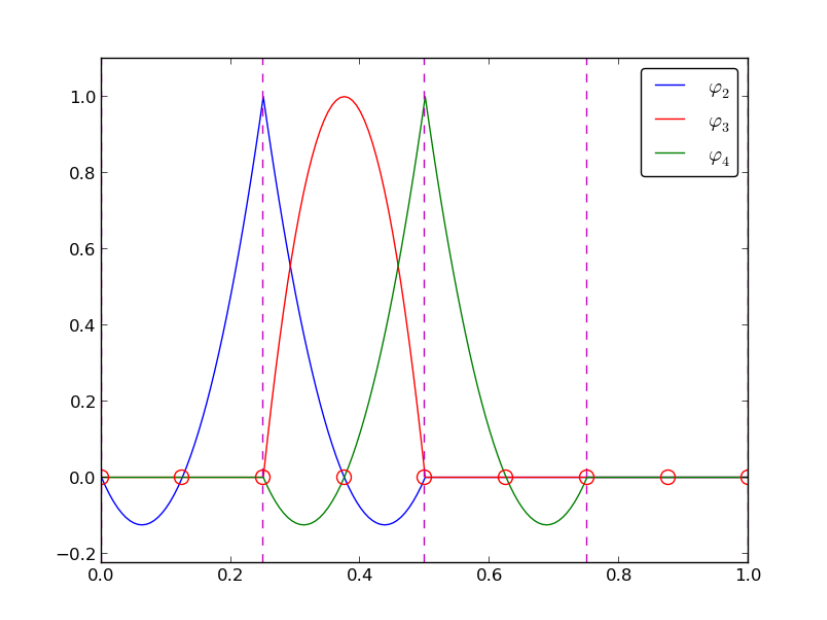

### **Interpolasi suatu fungsi $f(x)$ ke dalam $\mathcal{V}$**

Diberikan suatu himpunan fungsi basis $\phi_i(x)$ untuk suatu
ruang fungsi $\mathcal{V}$, maka jelas bahwa tidak semua fungsi
dapat direpresentasikan secara tepat tanpa kesalahan di dalam
$\mathcal{V}$. Sebagai contoh, jika diberikan suatu fungsi halus
$f(x)$ maka muncul pertanyaan bagaimana membangun pendekatan
$f_h(x) \in \mathcal{V}$ yang meminimalkan suatu ukuran kesalahan.

Sebenarnya terdapat beberapa pendekatan. Pendekatan yang paling
sederhana adalah *interpolasi* atau *proyeksi* dari $f$ ke dalam
$\mathcal{V}$, yang kita nyatakan sebagai $\pi f$, dan didefinisikan
sebagai fungsi $\pi f \in \mathcal{V}$ sehingga
$$
    \pi f (x) = \sum_{i=0}^N f(x_i)\phi(x)\tag{9}
$$

Diberikan sifat interpolasi dari polinomial Lagrange, maka jelas bahwa

$$
\pi f(x_j) = f(x_j)
$$

yaitu kedua fungsi tersebut memiliki kesalahan nol pada
derajat kebebasan (degrees of freedom).

Gambar 1.3 dari Larson dan Bengzon menunjukkan interpolan linear
dari suatu fungsi $f$ ke dalam satu elemen pada interval
$[x_0,x_1]$.
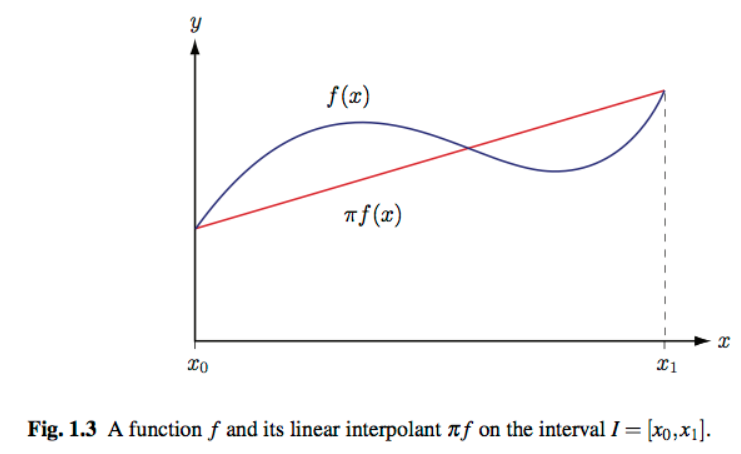

Gambar 1.4 dari Larson dan Bengzon menunjukkan interpolan linear
dari suatu fungsi $f$ ke dalam ruang fungsi linear sepenggal
$\mathcal{V}$.     
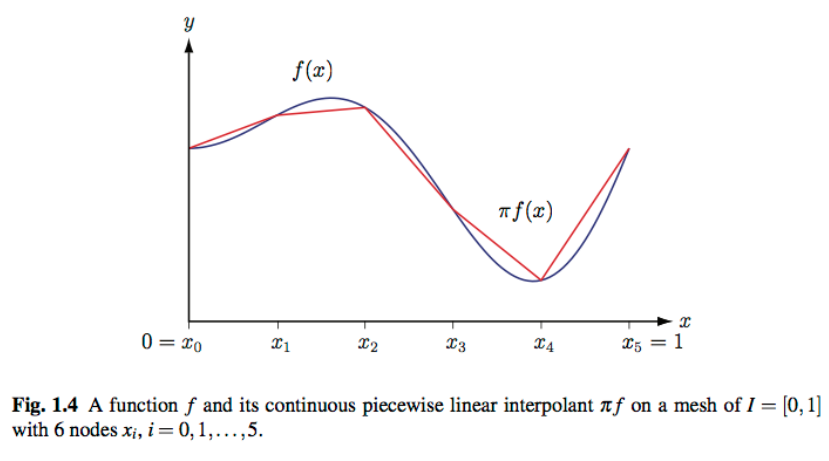

### 

### **Kesalahan Interpolasi**

Secara umum biasanya akan terdapat kesalahan antara $f(x)$
dan interpolannya $\pi f(x)$. Untuk mengukur kesalahan ini
biasanya diperlukan pendefinisian suatu norma, dan seperti
biasanya terdapat beberapa pilihan norma.

Namun demikian, suatu norma yang berguna dalam metode
elemen hingga adalah norma $L^2$ dari suatu fungsi
pada domain $\Omega$

$$
    ||f||_{L^2} = \left[ \int_\Omega f^2 dx\right]^{1/2}\tag{10}
$$


dan norma yang berkaitan dengannya

$$
    ||f||_{L^2(I)} = \left[ \int_I f^2 dx\right]^{1/2}\tag{11}
$$

pada suatu sub-interval $I$ (biasanya sebuah elemen).

Diberikan definisi-definisi tersebut, serta perilaku dari interpolasi
polinomial, maka relatif mudah untuk memperoleh perkiraan berikut
terhadap kesalahan interpolasi.


* Kesalahan interpolasi pada satu elemen linear $P_1$

$$ 
|| f - \pi f||_{L^2(I)} \leq C \Delta x^2||f''||_{L^2(I)}\tag{12}
$$
di mana $I=[x_i,x_{i+1}]$, $\Delta x = x_{i+1}-x_i$, $C$ adalah suatu
konstanta, dan $||f''||_{L^2(I)}$ merupakan ukuran kelengkungan
(curvature) fungsi pada interval tersebut. Jika $\Delta x = 0$ atau
fungsi bersifat linear pada interval tersebut, maka kesalahannya
adalah nol.

* Kesalahan interpolasi pada seluruh domain untuk fungsi polinomial sepenggal, kesalahan pada interpolan ke dalam
$\mathcal{V}$ merupakan penjumlahan dari kesalahan pada setiap elemen,
yaitu

$$ 
|| f - \pi f||^2_{L^2} \leq C \sum_{i=0}^N \Delta x_i^4||f''||^2_{L^2(I_i)}\tag{13}
$$


### **Konvergensi**   
Berdasarkan perkiraan kesalahan tersebut, jelas bahwa
interpolan akan konvergen menuju fungsi kontinu dalam
norma $L^2$ ketika $\Delta x \rightarrow 0$. Hal ini masuk
akal karena kita mengharapkan interpolan menjadi
pendekatan yang semakin baik terhadap $f$ ketika mesh
menjadi semakin halus.

Untuk fungsi $P_1$, kesalahan berkurang sebanding
dengan $\Delta x^2$. Interpolan orde lebih tinggi dari
fungsi yang halus smooth seharusnya
konvergen lebih cepat jika polinomial sepenggal orde
lebih tinggi tersebut merupakan pendekatan yang baik
terhadap fungsi kontinu $f$.

### **$L_2$ Proyeksi suatu fungsi $f(x)$ ke dalam $\mathcal{V}$**

Meskipun interpolan $\pi f$ konvergen menuju $f$ dalam
norma $L^2$ ketika $\Delta x \rightarrow 0$, ternyata
untuk $\Delta x$ yang tetap, fungsi tersebut bukanlah
fungsi di dalam $\mathcal{V}$ yang memiliki kesalahan
$L^2$ terkecil.

Untuk masalah tersebut, kita memerlukan proyeksi
ortogonal $L^2$ yaitu $P_h f$, yang merupakan fungsi
unik $v_h \in \mathcal{V}$ yang meminimalkan
$||f - v_h||_{L^2}$.

Gambar 1.6 dari Larson dan Bengzon menunjukkan
proyeksi ortogonal dari $f$ ke dalam $\mathcal{V}$
untuk fungsi $f(x)=x\sin(\pi x)$.

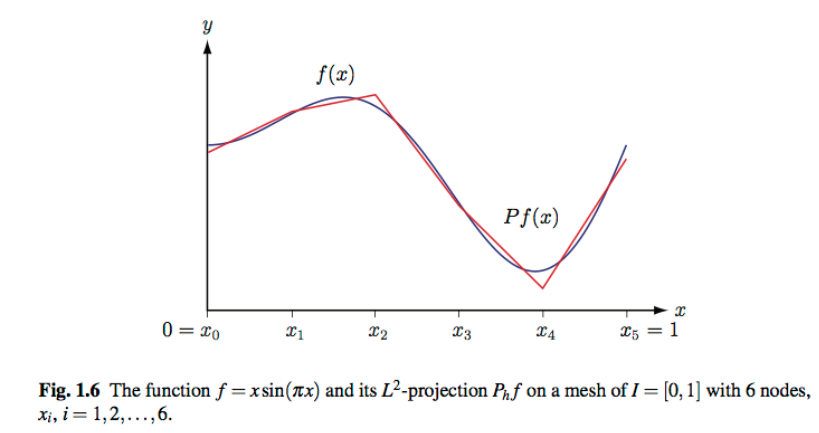

### **Hubungan dengan Proyeksi Least-Squares dalam Aljabar Linear**

Sebelum kita mengembangkan metode untuk menghitung
proyeksi ortogonal $L^2$ dari $f$ ke dalam $\mathcal{V}$,
yaitu $P_h f$, ada baiknya kita meninjau secara singkat
masalah proyeksi ortogonal yang terkait dalam aljabar linear.


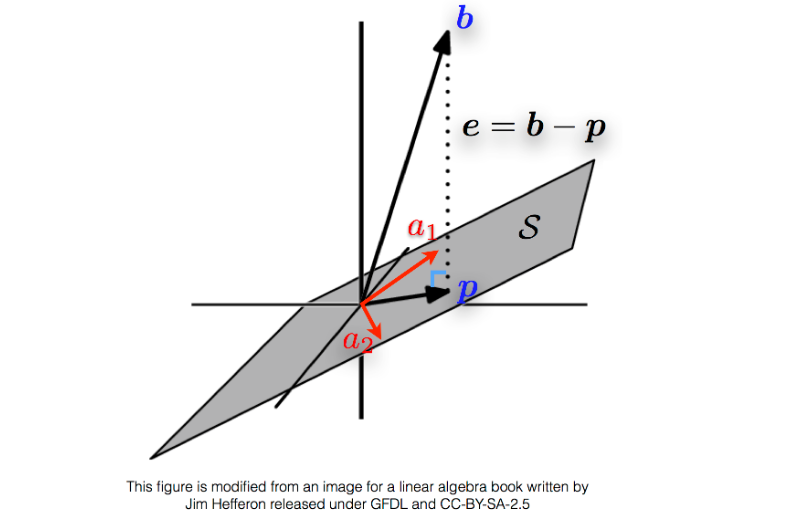

Pertimbangkan suatu subruang berdimensi dua $\mathcal{S}$ dari
$\mathbb{R}^3$ yang dibentang oleh dua vektor 3-D yang saling
bebas linear $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$, yaitu

$$
\cal S = \mathrm{span}<\boldsymbol{a}_1,\boldsymbol{a}_2>
$$ 

Misalkan $\boldsymbol{b}$ adalah sebuah vektor ketiga yang tidak
berada di dalam $\mathcal{S}$. Permasalahannya adalah mencari
titik $\boldsymbol{p} \in \mathcal{S}$ yang meminimalkan norma
Euclidean 2 dari kesalahan $\boldsymbol{e} = \boldsymbol{b} - \boldsymbol{p}$
di mana $||\boldsymbol{e}||_2 = \sqrt{\boldsymbol{e}^T \boldsymbol{e}}$

Dari pengamatan pada gambar, secara geometris kesalahan
terpendek diperoleh dengan mencari titik $\boldsymbol{p} = x_1\boldsymbol{a}_1 + x_2\boldsymbol{a}_2$
sedemikian sehingga $\boldsymbol{e}$ ortogonal terhadap bidang
$\mathcal{S}$. Jika kita mendefinisikan sebuah matriks


$$A =\begin{bmatrix}
\boldsymbol{a}_1 & \boldsymbol{a}_2
\end{bmatrix}
$$
yang kolom-kolomnya adalah vektor $\boldsymbol{a}_1$ dan
$\boldsymbol{a}_2$, maka $\boldsymbol{p} = A\boldsymbol{x}$ dengan
$$
\boldsymbol{x} =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

Agar $\boldsymbol{e}$ ortogonal terhadap setiap vektor dalam
$\mathcal{S}$, maka cukup jika $\boldsymbol{e}$ ortogonal terhadap
vektor basis $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$. Dengan
demikian syarat ortogonalitasnya adalah

$$
\boldsymbol{a}_i^T \boldsymbol{e} = 0
$$

untuk $i=1,2$. Hal ini ekuivalen dengan pernyataan

$$
A^T \boldsymbol{e} = \boldsymbol{0}
$$

(atau bahwa kesalahan berada pada $\textit{left null space}$ dari $A$).

Namun

$$\begin{aligned}
A^T\boldsymbol{e} &= A^T(\boldsymbol{b} - \boldsymbol{p}) \\
                  &= A^T(\boldsymbol{b} - A\boldsymbol{x}) \\
                  &= \boldsymbol{0}
\end{aligned}
$$

atau solusi $\textit{least-squares}$ memerlukan penyelesaian
$\textit{Normal Equations}$

$$
A^T A \boldsymbol{x} = A^T \boldsymbol{b}
$$

(meskipun secara numerik cara yang lebih baik untuk
menyelesaikannya adalah menggunakan faktorisasi QR,
yang juga merupakan aplikasi dari proyeksi ortogonal).

Jika solusi $\boldsymbol{x}$ telah diperoleh, maka proyeksinya
adalah

$$
\boldsymbol{p} = A\boldsymbol{x}.
$$

### **Proyeksi Ortogonal Suatu Fungsi ke Ruang Fungsi Diskrit**

Jika Anda memahami masalah sebelumnya dari aljabar linear, Anda akan menyadari bahwa proyeksi ortogonal suatu fungsi ke ruang fungsi diskrit pada dasarnya adalah masalah yang sama, hanya menggunakan pendekatan yang sedikit berbeda.

Masalah ini dapat dinyatakan sebagai berikut:

Diberikan suatu fungsi kontinu $f(x)$ dan ruang fungsi diskrit $\mathcal{V}_h$, tentukan fungsi $P_h f \in \mathcal{V}_h$ yang meminimalkan $|| f - P_h f||_{L^2}$.

Artinya, kita mencari fungsi dalam ruang $\mathcal{V}_h$ yang paling mendekati fungsi asli $f(x)$ jika diukur menggunakan norma $L^2$.

Sekali lagi, kita dapat membangun masalah ini secara geometris. Pertama, jika 
$P_h f \in \mathcal{V}_h$ maka fungsi tersebut dapat dituliskan dalam bentuk fungsi basis dari $\mathcal{V}_h$, yaitu

$$
P_h f(x) = \sum_{j=0}^{N} w_j \phi_j(x)
$$

Selanjutnya kita mendefinisikan residual (atau error) sebagai

$$
r(x) = f(x) - P_h f(x)
$$

Kemudian kita mensyaratkan bahwa residual tersebut harus $\textit{ortogonal}$ terhadap setiap fungsi 
$v_h \in \mathcal{V}_h$, dengan ortogonalitas fungsi didefinisikan terhadap norma $L^2$ dengan cara yang biasa. 
Artinya, dua fungsi $f$ dan $g$ dikatakan ortogonal jika

$$
\int_{\Omega} f g \, dx = 0
$$

Oleh karena itu, agar $r$ ortogonal terhadap setiap fungsi $v_h \in \mathcal{V}_h$, cukup jika $r$ ortogonal terhadap setiap fungsi basis dari $\mathcal{V}_h$. 
Untuk ruang fungsi berdimensi hingga, masalah ini menjadi mencari $P_h f \in \mathcal{V}_h$ sehingga

$$
\int_{\Omega} \phi_i(x) r(x)\, dx = 0
$$
untuk semua $i = 0, \ldots, N$.

Dengan menggunakan definisi $r(x)$ dan $P_h f(x)$ sebelumnya, masalah tersebut menjadi mencari vektor bobot 
$\boldsymbol{w} = [w_0, w_1, \ldots, w_N]^T$ sehingga

$$
\int_{\Omega} \phi_i(x) \sum_{j=0}^{N} w_j \phi_j(x)\, dx
=
\int_{\Omega} \phi_i(x) f(x)\, dx
$$

untuk semua $i = 0, \ldots, N$.

Ruas kanan (RHS) dari persamaan ini merupakan sekumpulan $N$ bilangan yang masing-masing menggambarkan 
hasil $\textit{inner product}$ $L^2$ antara $f$ dengan setiap fungsi basis. Dengan mendefinisikan

$$
\tilde{f}_i = \int_{\Omega} \phi_i(x) f(x)\, dx
\quad i = 0, \ldots, N
$$

maka ruas kanan dapat disusun menjadi sebuah vektor 
$\tilde{\boldsymbol{f}} \in \mathbb{R}^{N+1}$.

Ruas kiri (LHS) sedikit lebih kompleks, tetapi kita dapat menukar urutan penjumlahan dan integrasi sehingga diperoleh

$$
\int_{\Omega} \phi_i(x) \sum_{j=0}^{N} w_j \phi_j(x)\, dx
=
\sum_{j=0}^{N} w_j \int_{\Omega} \phi_i(x) \phi_j(x)\, dx
$$

Integral tentu terakhir ini menghasilkan sekumpulan bilangan dengan dua indeks

$$
M_{ij} = \int_{\Omega} \phi_i(x) \phi_j(x)\, dx
$$

yang mendefinisikan elemen-elemen dari $\textit{Mass Matrix}$ $M$.

Dengan demikian, masalah proyeksi ini sebenarnya dapat direduksi menjadi bentuk aljabar linear

$$
\sum_{j=0}^{N} M_{ij} w_j = \tilde{f}_i
$$

atau dalam notasi matriks-vektor

$$
M \boldsymbol{w} = \tilde{\boldsymbol{f}}
$$

Setelah $\boldsymbol{w}$ diperoleh dari sistem persamaan tersebut, maka fungsi proyeksi 
$P_h f(x)$ dapat ditentukan dari bobot dan fungsi basisnya.

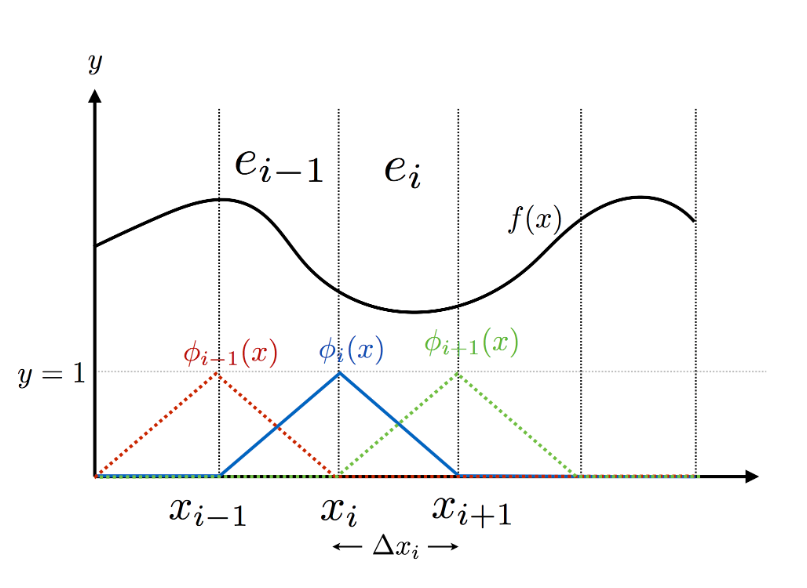      
Gambar 9 menunjukkan seluruh komponen yang diperlukan untuk menyusun matriks massa $M$ dan vektor beban $\tilde{\boldsymbol{f}}$.

### **Struktur Matriks Massa**

Struktur matriks massa dapat dipahami dengan meninjau fungsi basis pada
interval satu dimensi yang terdiri dari $N$ elemen. Matriks massa $M$
merupakan matriks berukuran $(N+1)\times(N+1)$ dengan elemen yang
didefinisikan sebagai

$$
M_{ij} = \int_\Omega \phi_i(x)\phi_j(x)\, dx
$$
Jika fungsi basis bersifat ortonormal, misalnya fungsi sinus, cosinus,
atau polinomial Chebyshev, maka matriks massa akan sama dengan matriks
identitas $I$. Namun pada metode elemen hingga dengan fungsi basis
berbentuk $\textit{hat function}$, matriks massa menjadi matriks jarang
$(\textit{sparse})$ karena fungsi basis yang tidak memiliki daerah
dukungan yang sama menghasilkan $M_{ij}=0$.

Untuk kasus satu dimensi dengan fungsi basis $P_1$, matriks massa
memiliki bentuk tridiagonal. Hal ini terjadi karena hanya interaksi
antara fungsi basis $\phi_i$ dengan dua tetangganya $\phi_{i-1}$ dan
$\phi_{i+1}$ yang menghasilkan nilai tidak nol.

Elemen-elemen pada baris ke-$i$ dari matriks massa adalah

\begin{align}
M_{i,i-1} &= \int_\Omega \phi_{i}\phi_{i-1} \, dx
          = \int_{x_{i-1}}^{x_i} \phi_{i}\phi_{i-1} \, dx \\
M_{i,i} &= \int_\Omega \phi_{i}\phi_{i} \, dx
        = \int_{x_{i-1}}^{x_{i+1}} \phi_{i}\phi_{i} \, dx \\
M_{i,i+1} &= \int_\Omega \phi_{i}\phi_{i+1} \, dx
          = \int_{x_i}^{x_{i+1}} \phi_{i}\phi_{i+1} \, dx
\end{align}

Elemen pertama berasal dari elemen $e_{i-1}$, elemen terakhir berasal
dari elemen $e_i$, sedangkan elemen diagonal merupakan kontribusi dari
keduanya

$$
M_{i,i} =
\int_{x_{i-1}}^{x_i} \phi_{i}\phi_{i} \, dx +
\int_{x_i}^{x_{i+1}} \phi_{i}\phi_{i} \, dx
$$

Untuk fungsi basis $P_1$, nilai elemen matriks dapat dihitung secara
analitik. Sebagai contoh

$$
M_{i,i-1} =
\int_{x_{i-1}}^{x_i}
\frac{x_i - x}{\Delta x_{i-1}}
\frac{x - x_{i-1}}{\Delta x_{i-1}} dx
$$

Perhitungan integral menjadi lebih sederhana dengan transformasi afin

$$
x(s) = x_{i-1} + s \Delta x_{i-1}
$$

dengan $s \in [0,1]$ dan $dx = \Delta x_{i-1} ds$, sehingga

$$
M_{i,i-1} =
\Delta x_{i-1}\int_0^1 (1-s)s\, ds
$$

$$
=
\Delta x_{i-1}
\left(\frac{s^2}{2}-\frac{s^3}{3}\right)\Bigg|_0^1
$$

$$
=
\frac{\Delta x_{i-1}}{6}
$$

Dengan cara yang sama diperoleh

\begin{align}
M_{i,i} &=
\Delta x_{i-1}\int_0^1 s^2 ds +
\Delta x_i\int_0^1 (1-s)^2 ds
=
\frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3}
\\
M_{i,i+1} &=
\Delta x_i\int_0^1 s(1-s) ds
=
\frac{\Delta x_i}{6}
\end{align}

Sehingga pola satu baris matriks massa dapat dituliskan sebagai

$$
M_i =
\begin{bmatrix}
\frac{\Delta x_{i-1}}{6} &
\frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3} &
\frac{\Delta x_i}{6}
\end{bmatrix}
$$

Bentuk matriks massa global adalah

$$
M =
\begin{bmatrix}
\frac{\Delta x_0}{3} & \frac{\Delta x_0}{6} & & & \\
\frac{\Delta x_0}{6} &
\frac{\Delta x_0}{3} + \frac{\Delta x_1}{3} &
\frac{\Delta x_1}{6} & & \\
&
\frac{\Delta x_1}{6} &
\frac{\Delta x_1}{3} + \frac{\Delta x_2}{3} &
\frac{\Delta x_2}{6} & \\
& & \ddots & \ddots & \ddots \\
& & &
\frac{\Delta x_N}{6} &
\frac{\Delta x_N}{3}
\end{bmatrix}
$$

### **Mekanika: Perakitan Elemen (Element-wise Assembly)**

Meskipun matriks massa global dapat disusun secara langsung seperti
yang dijelaskan sebelumnya, pendekatan yang lebih baik adalah dengan
melakukan perulangan pada setiap elemen dan menghitung kontribusi lokal
dari masing-masing elemen terhadap matriks massa global.

Sebagai langkah awal, matriks massa $M$ dapat diuraikan menjadi jumlah
dari beberapa matriks blok yang lebih sederhana

$$
M =
\begin{bmatrix}
\frac{\Delta x_0}{3}  & \frac{\Delta x_0}{6} & &  \\
\frac{\Delta x_0}{6}  & \frac{\Delta x_0}{3}  & & \\
&&& \\
&&& \\
&&& \\
&&&
\end{bmatrix}
+
\begin{bmatrix}
&&& \\
& \frac{\Delta x_1}{3}  & \frac{\Delta x_1}{6}   & \\
& \frac{\Delta x_1}{6}  & \frac{\Delta x_1}{3}  &  \\
&&& \\
&&& \\
&&&
\end{bmatrix}
+ \ldots +
\begin{bmatrix}
&&& \\
&&& \\
&&& \\
&&& \\
& & \frac{\Delta x_N}{3}  & \frac{\Delta x_N}{6} \\
& & \frac{\Delta x_N}{6}  & \frac{\Delta x_N}{3}
\end{bmatrix}
$$

atau dapat dituliskan secara ringkas sebagai
$$
M = M^{e_0} + M^{e_1} + \ldots + M^{e_N}
$$

dengan


$$M^{e_i} =
\frac{\Delta x_i}{6}
\begin{bmatrix}
2 & 1\\
1 & 2
\end{bmatrix}
$$

yang merupakan matriks massa lokal untuk elemen $e_i$.

Dari Gambar 3 dapat dilihat bahwa matriks massa elemen dapat
dinyatakan sepenuhnya menggunakan fungsi basis lokal
$N_0(t)$ dan $N_1(t)$ pada sistem koordinat lokal

$$
M^{e_i} =
\Delta x_i
\begin{bmatrix}
\int_0^1 N_0^2 \, dt & \int_0^1 N_0 N_1 \, dt \\
\int_0^1 N_0 N_1 \, dt & \int_0^1 N_1^2 \, dt
\end{bmatrix}
$$

Setiap elemen matriks lokal tersebut berkaitan langsung dengan
komponen matriks massa global

$$
M^{e_i} =
\begin{bmatrix}
M_{i,i} & M_{i,i+1} \\
M_{i+1,i} & M_{i+1,i+1}
\end{bmatrix}
$$

Dengan demikian, algoritma penyusunan matriks massa global adalah:

* Melakukan perulangan pada setiap elemen $i=0,\ldots,N$
* Menghitung matriks massa lokal $M^{e_i}$
* Menambahkan kontribusi tersebut ke dalam matriks massa global

Proses yang serupa juga digunakan untuk menyusun vektor beban
$(\textit{load vector})$ $\tilde{\boldsymbol{f}}$ dengan langkah:

* Melakukan perulangan pada setiap elemen $i=0,\ldots,N$
* Menghitung kontribusi elemen terhadap vektor beban


$$
\tilde{\boldsymbol{f}}^{e_i} =
\begin{bmatrix}
\int_{x_{i-1}}^{x_i} N_0(x)f(x) \, dx \\
\int_{x_{i-1}}^{x_i} N_1(x)f(x) \, dx
\end{bmatrix}
=
\begin{bmatrix}
\tilde{f}_i \\
\tilde{f}_{i+1}
\end{bmatrix}
$$


### **Konvergensi/Optimalitas**

Untuk pembahasan selanjutnya...

### **Penyelesaian Persamaan Poisson 1-D dengan FEM**

Masalah proyeksi sebenarnya sudah menyediakan sebagian besar mekanisme
yang diperlukan untuk menggunakan metode FEM dalam menyelesaikan
persamaan diferensial parsial (PDE). Di sini kita akan mempertimbangkan
masalah nilai batas dua titik paling sederhana dalam satu dimensi.

$$
-\frac{d^2 u}{dx^2} = f(x)\quad \mathrm{pada} \quad \Omega = [0,1]
$$

dengan kondisi batas Dirichlet

$$
u(0) = u(1) = 0
$$

Jika kita membuatnya lebih sederhana lagi dengan mengambil $f(x)=1$,
maka kita memperoleh masalah \textit{Manufactured Solution} (MMS)
yang mudah dengan solusi yang sudah diketahui

$$
u(x) = \frac{1}{2}x(1 - x)
$$

Bagian-bagian berikutnya akan memberikan langkah-langkah singkat
untuk membangun permasalahan Metode Elemen Hingga Galerkin.

## **Memilih Ruang Fungsi (Mesh + Elemen)**

Langkah pertama adalah memilih ruang fungsi $\mathcal{V}$ untuk
mendekati solusi diskrit. Interval satuan dibagi menjadi $N$
elemen dengan ukuran $h_j$ (tidak harus sama).

Solusi kemudian didekati menggunakan fungsi linear sepotong-sepotong
($P_1$), yaitu

$$
u_h = \sum_{j=0}^N w_j\phi_j(x)
$$

di mana $\phi_j(x)$ adalah fungsi basis \textit{hat function}
untuk $P_1$.

Meskipun bentuk kuat $(\textit{strong form})$ dari PDE membutuhkan fungsi
yang turunan keduanya konstan, sedangkan fungsi $P_1$ memiliki turunan
kedua yang tidak kontinu di batas elemen, pendekatan ini tetap dapat
digunakan dengan baik untuk menyelesaikan masalah ini dalam norma
tertentu.

\subsection{Membentuk Weak Form}

Seperti telah dijelaskan, fungsi diskrit $u_h(x)$ tidak dapat menjadi
solusi langsung dari persamaan kuat (Eq. \ref{strongform}). 
Namun untuk setiap fungsi, kita tetap dapat menghitung
$\textit{residual}$ dengan mensubstitusikannya ke dalam persamaan kuat

$$
r(x) = -\frac{d^2 u_h}{dx^2} - f(x).
$$

Jika $u_h$ adalah solusi tepat dari (Eq. \ref{strongform}),
maka $r(x)=0$. Tetapi karena ruang fungsi $\mathcal V$
tidak dapat memuat solusi kuat secara langsung,
maka masalahnya diubah menjadi


>Menentukan $u_h$ dalam $\mathcal V$ yang meminimalkan
$||r||_{L^2}$.`

Seperti pada masalah proyeksi sebelumnya,
persoalan ini dapat ditulis sebagai

>Menentukan $u_h$ dalam $\mathcal V$ sehingga

>$$\int_\Omega v r \, dx =0$$
>untuk semua $v$ dalam $\mathcal V$.


Artinya kita mencari solusi di mana residualnya
tegak lurus (orthogonal) terhadap ruang fungsi
piecewise linear pada mesh.

Dengan memasukkan bentuk residual,
persamaan menjadi

>Menentukan $u_h$ dalam $\mathcal V$ sehingga
>$$ \int_\Omega v \frac{d^2 u_h}{dx^2} dx
= \int_\Omega vf\, dx
$$
>untuk semua $v$ dalam $\mathcal V$.

#### **Beberapa Istilah Penting**

Persamaan Persamaan Bentuk Lemah (Weak Form) dikenal sebagai $\textbf{weak form}$
atau $\textbf{variational form}$ dari suatu masalah.
Dalam metode elemen hingga (FEM), terdapat beberapa istilah yang
sering digunakan, yaitu:

* $u_h$ disebut sebagai $\textit{trial function}$, yaitu fungsi
perkiraan yang digunakan sebagai solusi dalam perhitungan residual.

* $v$ disebut sebagai $\textit{test function}$, yaitu fungsi dalam
ruang $\mathcal V$ yang digunakan untuk menguji kondisi ortogonalitas
dari residual.

* Sisi kiri dari persamaan Bentuk Lemah (Weak Form)
$$
a(u_h,v) = -\int_\Omega v \frac{d^2 u_h}{dx^2} dx
$$
disebut sebagai $\textbf{bentuk bilinear}$ $(\textit{bilinear form})$,
karena melibatkan dua fungsi $u$ dan $v$ serta bersifat linear
terhadap masing-masing fungsi tersebut.

* Sisi kanan dari persamaan Bentuk Lemah (Weak Form)
$$
L(v) = \int_\Omega vf\, dx
$$
disebut sebagai $\textbf{bentuk linear}$ $(\textit{linear form})$,
karena menghasilkan satu nilai skalar untuk setiap fungsi $v$.

* Bentuk singkat yang sering digunakan untuk menuliskan
persoalan variasional ini adalah
$$
a(u,v) = L(v)
$$

#### **Beberapa Terminologi**

Persamaan weak form dikenal sebagai weak form atau variational form dari suatu masalah. Dalam metode $\textit{Finite Element Method} (FEM)$, terdapat beberapa istilah penting yang sering digunakan:

* $u_h$ disebut sebagai $\textit{trial function}$, yaitu fungsi perkiraan yang digunakan untuk mendekati solusi sebenarnya.
* $v$ disebut sebagai $\textit{test function}$, yaitu fungsi dalam ruang $\mathcal{V}$ yang digunakan untuk menguji ortogonalitas residual.
* Bagian kiri dari Persamaan \eqref{eq:wf}
$$
a(u_h,v) = -\int_\Omega v \frac{d^2 u_h}{dx^2} dx
$$
disebut sebagai \textbf{bilinear form} $a(u,v)$. Bentuk ini bergantung pada dua fungsi ($u$ dan $v$) dan bersifat linear terhadap keduanya.
* Bagian kanan dari Persamaan \eqref{eq:wf}
$$
L(v) = \int_\Omega vf\, dx
$$
disebut sebagai $\textbf{linear form}$ $L(v)$, yang menghasilkan nilai skalar untuk setiap fungsi $v$.

Secara ringkas, masalah variasional ini sering ditulis dalam bentuk

$$
a(u,v) = L(v).
$$

**Integrasikan secara Bertahap**

Bentuk bilinear pada sisi kiri Persamaan weak form masih kurang praktis, terutama jika $u_h$ berada pada ruang $P_1$. Salah satu kelebihan bentuk variasional adalah kita dapat menggunakan $\textbf{integration by parts}$ untuk memindahkan sebagian turunan dari $\textit{trial function}$ ke $\textit{test function}$.

Diketahui bahwa
$$
\frac{d^2 u_h}{dx^2} = \frac{d}{dx}\frac{du_h}{dx}
$$

dan berdasarkan aturan turunan hasil kali diperoleh
$$
\frac{d}{dx} \left(v \frac{du_h}{dx}\right) 
= v\frac{d^2 u}{dx^2} + \frac{dv}{dx}\frac{du_h}{dx}.
$$

Sehingga diperoleh

$$
\begin{aligned}
a(u_h,v) &= -\int_\Omega v \frac{d^2 u_h}{dx^2} dx \\
         &= \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx 
         - \int_\Omega \frac{d}{dx} \left(v \frac{du_h}{dx}\right) dx \\
         &= \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx 
         - \left. v \frac{du_h}{dx}\right|_{\partial\Omega}
\end{aligned}
$$

Suku terakhir bergantung pada nilai fungsi uji dan turunan pertama $u_h$ di batas domain. Oleh karena itu, kondisi batas $\textit{Neumann}$ atau $\textit{flux boundary condition}$ dapat dimasukkan secara alami dalam formulasi FEM.

Jika suku batas diabaikan untuk sementara, maka hasil $\textit{integration by parts}$ memberikan bentuk bilinear yang lebih sederhana:

$$
a(u_h,v) = \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx.
$$

Bentuk ini hanya bergantung pada gradien dari $\textit{test function}$ dan $\textit{trial function}$. Pada ruang $P_1$, gradien tersebut bersifat $\textit{piecewise constant}$.

#### **Bentuk Lemah untuk Ruang Fungsi Berdimensi Hingga**

Semua konsep sebelumnya berlaku baik untuk ruang fungsi berdimensi tak hingga maupun berdimensi hingga. Namun, pada ruang fungsi berdimensi hingga dengan jumlah fungsi basis tetap, bentuk linear dan bilinear dapat dinyatakan sebagai operasi aljabar linear. Struktur ini mirip dengan yang telah muncul pada masalah proyeksi dan juga berlaku untuk persamaan Poisson.

Pertama, solusi pendekatan dinyatakan sebagai kombinasi fungsi basis
$$
u_h(x) = \sum_{j=0}^N w_j \phi_j(x)
$$

Kemudian setiap fungsi basis dipilih sebagai $\textit{test function}$. Dengan demikian, masalah variasional $a(v,u_h)=L(v)$ menjadi:

* Cari $\boldsymbol{w}\in \mathbb{R}^{N+1}$ sehingga
$$
\int_\Omega \frac{d\phi_i}{dx} \sum_{j=0}^N w_j \frac{d\phi_j}{dx} \, dx
=
\int_\Omega \phi_i f \, dx
$$

Dengan menukar urutan penjumlahan dan integrasi, diperoleh

$$
\sum_{j=0}^N w_j
\int_\Omega
\frac{d\phi_i}{dx}
\frac{d\phi_j}{dx}
\, dx
=
\int_\Omega \phi_i f \, dx
$$

atau

$$
\sum_{j=0}^N A_{ij} w_j = \tilde{f}_i
$$

dengan

$$
A_{ij} =
\int_\Omega
\frac{d\phi_i}{dx}
\frac{d\phi_j}{dx}
\, dx
\quad
\tilde{f}_i =
\int_\Omega
\phi_i f \, dx
$$

Secara ringkas dapat ditulis sebagai

$$
A\boldsymbol{w} = \tilde{\boldsymbol{f}}
$$

di mana $A$ disebut sebagai $\textbf{stiffness matrix}$ dan $\tilde{\boldsymbol{f}}$ disebut sebagai $\textbf{load vector}$. Istilah ini berasal dari aplikasi metode elemen hingga pada masalah elastisitas di bidang rekayasa, sehingga istilah seperti $\textit{stiffness}$ dan $\textit{load}$ digunakan dalam penamaannya.

Dengan demikian, bentuk lemah dari persamaan diferensial parsial pada Persamaan strongform berubah menjadi sistem aljabar linear
$$
A\boldsymbol{w} = \tilde{\boldsymbol{f}}.
$$

Hal ini serupa dengan bentuk lemah pada masalah proyeksi $u_h=f$, yang menghasilkan sistem
$$
M\boldsymbol{w} = \tilde{\boldsymbol{f}},
$$

di mana $M$ adalah $\textbf{mass matrix}$, sedangkan $\textit{load vector}$-nya tetap sama.

#### **Perakitan**

Perakitan $(\textit{assembly})$ matriks kekakuan global dan vektor beban global dilakukan dengan cara yang sama seperti pada masalah proyeksi. Bahkan, vektor beban pada kedua masalah tersebut identik. Perbedaannya hanya pada matriks kekakuan yang sekarang melibatkan turunan fungsi basis. Untuk elemen $P_1$, proses perhitungannya masih cukup sederhana.

Pertama, disusun $\textbf{element stiffness matrix}$

$$
  A^{e_i} = \begin{bmatrix}
  \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}^2 dx & \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx \\
  \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx & \int_{x_i}^{x_{i+1}} \frac{dN_1}{dx}^2 dx \\
\end{bmatrix}
$$

dengan

$$
N_0(x) = \frac{x_{i+1} - x}{\Delta x_i}
\quad
N_1(x) = \frac{x - x_i}{\Delta x_i}
$$

sebagai fungsi basis lokal (atau $\textit{shape functions}$), yang merupakan polinom Lagrange orde 1.

Menggunakan transformasi affine standar $x = x_i + t h_i$, fungsi basis ditulis dalam koordinat lokal:

$$
N_0(t) = 1 - t
\quad
N_1(t) = t
$$

Turunan terhadap $x$ diberikan oleh

$$
\frac{dN_i}{dx} = \frac{dN_i}{dt}\frac{dt}{dx} = \frac{1}{\Delta x_i}\frac{dN_i}{dt}
$$

Sebagai contoh, elemen pertama matriks kekakuan menjadi

$$
A^{e_i}_{00} = \frac{1}{\Delta x_i}\int_0^1 dt = \frac{1}{\Delta x_i}
$$

Sehingga matriks kekakuan elemen diperoleh

$$
A^{e_i} = \frac{1}{\Delta x_i}\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}
$$

Matriks kekakuan global kemudian dirakit dengan pola $(\textit{stencil})$ untuk titik interior

$$
M_i =
\begin{bmatrix}
-\frac{1}{\Delta x_{i-1}} &
\frac{1}{\Delta x_{i-1}} + \frac{1}{\Delta x_i} &
-\frac{1}{\Delta x_i}
\end{bmatrix}
$$

Untuk mesh dengan jarak seragam $h_0,\ldots,h_N = h$, bentuknya menjadi

$$
M_i =
\frac{1}{\Delta x}
\begin{bmatrix}
-1 & 2 & -1
\end{bmatrix}
$$

yang identik dengan $\textit{finite difference stencil}$ orde dua untuk turunan kedua.

Matriks globalnya menjadi

$$
M =
\frac{1}{\Delta x}
\begin{bmatrix}
1  & -1 & & & & \\
-1 & 2 & -1 & & & \\
& -1  & 2 & -1  & & \\
& & \ddots & \ddots & \ddots & \\
& & &   &  -1 & 2
\end{bmatrix}
$$

Dengan demikian, untuk persamaan Poisson 1-D dengan gaya konstan dan mesh seragam, metode Galerkin Finite Element dengan elemen $P_1$ menghasilkan diskretisasi yang sama dengan metode $\textit{second-order finite difference}$.

#### **Kondisi Batas**

Untuk melengkapi bentuk diskret dari persamaan diferensial eliptik ini, kita perlu menerapkan $\textit{boundary conditions}$.

Pada kondisi batas $\textbf{Neumann (flux)}$, kondisi ini dapat langsung dimasukkan dalam bentuk lemah $(\textit{weak form})$. Hal ini muncul dari proses $\textit{integration by parts}$ pada bentuk bilinear yang menghasilkan suku tambahan

$$
\left. v \frac{du_h}{dx}\right|_{\partial\Omega}
$$

Sebelumnya suku ini diabaikan karena sesuai dengan kondisi $\teKondisi Batasxtit{no-flux}$, yaitu

$$
\frac{du_h}{dx} = 0.
$$

Namun, pada kondisi Neumann yang lebih umum, gradien pada batas diketahui, misalnya

$$
\frac{du_h}{dx} = \alpha.
$$

Dalam kasus ini, nilai $\alpha$ langsung disubstitusikan ke dalam suku tersebut. Karena suku ini hanya bergantung pada fungsi uji $v$, maka nilainya dapat dihitung dan ditambahkan ke dalam \textit{load vector}.

Untuk kondisi batas $\textbf{Dirichlet}$, penerapannya sedikit lebih kompleks. Jika nilai fungsi pada batas sudah diketahui, maka derajat kebebasan pada titik batas sebenarnya tidak termasuk dalam ruang fungsi. Oleh karena itu, sistem persamaan dapat diselesaikan hanya untuk titik interior, sedangkan nilai batas dimasukkan kembali saat merekonstruksi solusi.

Pendekatan lain adalah dengan merakit sistem persamaan seperti biasa, kemudian setelah proses $\textit{assembly}$, matriks dimodifikasi dengan cara:
* Mengganti elemen diagonal dengan nilai 1
* Menjadikan elemen lain pada baris tersebut bernilai 0
* Memasukkan nilai batas yang sesuai ke dalam $\textit{load vector}$


Namun cara ini dapat menyebabkan matriks kekakuan kehilangan sifat simetrinya. Oleh karena itu, pendekatan yang lebih baik adalah dengan meniadakan baik baris maupun kolom yang bersangkutan, kemudian menyesuaikan $\textit{load vector}$ sesuai kebutuhan.

Perangkat Lunak Tingkat Lanjut untuk Pemodelan Elemen Hingga

Walaupun tidak terlalu sulit membuat skrip Python sederhana untuk menyelesaikan persamaan Poisson 1-D dengan elemen linear, membuat program yang benar-benar modular dan dapat diperluas ke dimensi lebih tinggi, jenis elemen berbeda, atau solver lain merupakan pekerjaan yang cukup kompleks.  

Untungnya, telah tersedia berbagai perangkat lunak dan pustaka (\textit{library}) FEM, baik yang bersifat komersial maupun \textit{open-source}. Salah satu yang cukup menarik secara matematis maupun komputasional adalah \textbf{FEniCS} yang dikembangkan oleh \textit{FEniCS Project}.

\begin{center}
\includegraphics[width=0.8\textwidth]{fenics_banner.png}
\end{center}

FEniCS menyediakan seperangkat pustaka dan alat komputasi untuk merancang serta menyelesaikan masalah berbasis \textit{Partial Differential Equations} (PDE) menggunakan metode \textit{Finite Element Method} (FEM) secara efisien.

Beberapa fitur utama dari FEniCS antara lain:

\begin{itemize}
\item Menyediakan antarmuka dalam bahasa \textbf{C++} dan \textbf{Python}.
\item Memiliki bahasa tingkat tinggi bernama \textbf{UFL (Unified Form Language)} untuk menuliskan \textit{weak form} yang bentuknya sangat mirip dengan persamaan integral matematis.
\item UFL mendukung:
\begin{itemize}
\item berbagai jenis elemen kontinu dan diskontinu,
\item operator vektor dan tensor tingkat tinggi seperti \textit{Div}, \textit{Grad}, dan \textit{Curl},
\item diferensiasi otomatis dari bentuk matematis, yang sangat berguna untuk masalah nonlinier.
\end{itemize}
\item \textbf{FFC (FEniCS Form Compiler)}: program Python yang menerjemahkan UFL menjadi kode C++ yang dapat dikompilasi secara otomatis untuk proses perakitan (\textit{assembly}) elemen hingga.
\item \textbf{DOLFIN}: pustaka utama yang menangani mesh, proses assembly, solver, serta input/output dan visualisasi.
\item Mendukung integrasi dengan pustaka solver numerik tingkat lanjut seperti \textbf{PETSc} dan \textbf{Trilinos}.
\end{itemize}

Untuk memahami cara kerjanya, biasanya lebih mudah melihat langsung contoh kode Python. Contoh berikut diadaptasi dari salah satu demo resmi FEniCS untuk menyelesaikan persamaan Poisson, tetapi dimodifikasi untuk kasus 1-D yang telah dibahas sebelumnya.

In [1]:
"""This demo program solves Poisson's equation in 1-D

    - d^2 u/ dx^2  = f(x)

on the unit interval with source f given by

    f(x) = 1

and homogeneous Dirichlet boundary conditions given by

    u(0)=u(1) = 0        for x = 0 or x = 1
"""

# Modified from demo_poisson.py from the FEniCS demos


# Begin demo

from dolfin import *

# Create mesh and define function space
mesh = UnitIntervalMesh(32)
V = FunctionSpace(mesh, "Lagrange", 1)

# Define Dirichlet boundary (x = 0 or x = 1)
def boundary(x):
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS

# Define boundary condition
u0 = Constant(0.0)
bc = DirichletBC(V, u0, boundary)

# Define variational problem
u = TrialFunction(V)
v = TestFunction(V)
f = Constant(1.)
a = v.dx(0)*u.dx(0)*dx
L = f*v*dx 

# Compute solution
u = Function(V)
solve(a == L, u, bc)

# Save solution in VTK format
file = File("poisson.pvd")
file << u


# Plot solution
plot(u, interactive=True)

ModuleNotFoundError: No module named 'dolfin'

And here is the same problem but with a Neumann boundary condition on the right-hand side such that
\[
\frac{du_h}{dx} = \alpha
\]
which simply adds one more term to the linear form. This additional term arises from the surface integrals of the bilinear form.

In [ ]:
"""This demo program solves Poisson's equation in 1-D

    - d^2 u/ dx^2  = f(x)

on the unit interval with source f given by

    f(x) = 1

and boundary conditions given by

    u(0)= 0        for x = 0 
    du/dx = alpha for x=1
"""

# Modified from demo_poisson.py from the FEniCS demos


# Begin demo

from dolfin import *

# Create mesh and define function space
mesh = UnitIntervalMesh(32)
V = FunctionSpace(mesh, "Lagrange", 1)

# Define Dirichlet boundary (x = 0 )
def boundary(x):
    return x[0] < DOLFIN_EPS 

# Define boundary condition
# Dirichlet
u0 = Constant(0.0)
bc = DirichletBC(V, u0, boundary)
# Neumann:  du/dx = \alpha
alpha=Constant(-.25)

# Define variational problem
u = TrialFunction(V)
v = TestFunction(V)
f = Constant(1.)
a = v.dx(0)*u.dx(0)*dx
L = v*f*dx + v*alpha*ds

# Compute solution
u = Function(V)
solve(a == L, u, bc)

# Save solution in VTK format
file = File("poisson.pvd")
file << u


# Plot solution
#plot(u, interactive=True)
plot(u)

\section{Finite Elements in Higher Dimensions}

Salah satu keunggulan dari FEniCS adalah kemampuannya untuk menuliskan dan menyelesaikan persamaan diferensial parsial (PDE) berdimensi lebih tinggi dengan usaha yang hampir sama seperti pada kasus 1-D. Sebagai contoh, kita akan mempertimbangkan masalah berikut beserta implementasinya menggunakan FEniCS.

\subsection{Strong Form}

Kita ingin menyelesaikan masalah Poisson umum pada suatu domain persegi panjang

$$
    -\nabla\cdot \alpha(x)\nabla u = f(x) \quad \mathrm{pada} \quad \Omega=[0,2]\times[0,1]
$$

dengan $\alpha(x,y) > 0$ pada domain $\Omega$ (jika $\alpha=1$ maka persamaan ini menjadi persamaan Poisson biasa). Sumber gaya diberikan oleh

$$
    f(\boldsymbol{x}) = 10 \exp\left[ -((x - 1)^2 + (y - 1/2)^2)/0.02\right]
$$

Kondisi batas Dirichlet diberikan pada arah $x$

$$
    u(0,y) = u(2,y) =0
$$

Sedangkan pada batas arah $y$ diberikan kondisi batas Neumann (flux)

$$
    \alpha(x)\nabla u\cdot\hat{n} = \sin(5x) \quad \mathrm{pada} \quad y=0,1
$$

\subsection{Weak Form}

Untuk membentuk weak form, kita memilih suatu ruang fungsi $\cal V$, misalnya fungsi linear potongan (piecewise linear) pada elemen segitiga. Masalah variasionalnya dapat ditulis sebagai

\begin{quote}
Temukan $u$ di dalam $\cal V$ sehingga
\end{quote}

$$
    -\int_\Omega v\nabla\cdot \alpha\nabla u \, dx = \int_\Omega vf \, dx
$$

untuk semua fungsi uji $v$ di dalam $\cal V$.

Dengan melakukan integrasi parsial pada bentuk bilinear, diperoleh

\begin{align}
    -\int_\Omega v\nabla\cdot (\alpha \nabla u) dx 
    &= \int_\Omega \nabla v\cdot (\alpha \nabla u) dx - \int_\Omega \nabla\cdot v(\alpha\nabla u) dx \\
    &= \int_\Omega \nabla v\cdot (\alpha \nabla u) dx - \int_{\partial\Omega}  v (\alpha\nabla u\cdot\hat{n}) ds
\end{align}

Pada langkah terakhir digunakan teorema divergensi Gauss untuk memindahkan integral ke batas domain, sehingga kondisi batas Neumann dapat langsung dimasukkan.

Dalam notasi bentuk variasional, weak form dapat ditulis sebagai

$$
a(u,v) = L(v)
$$

dengan

\begin{align}
    a(u,v) &= \int_\Omega \nabla v\cdot \alpha \nabla u \, dx \\
    L(v) &= \int_\Omega vf \, dx + \int_{\partial\Omega}  v g \, ds
\end{align}

dengan

$$
    g(x,y) = \alpha\nabla u\cdot\hat{n} = \sin(5x)
$$

Menariknya, kode FEniCS untuk menyelesaikan masalah ini hampir sama dengan bentuk matematis yang baru saja kita tuliskan.